## Autor: David Roca Tauste

### Actividades 1-5
---

# ACTIVIDAD 1
# ENTREGA 1

### a) ¿Cómo se llama el paquete donde se encuentran los datasets que tiene la librería?
El paquete donde se encuentran los datasets se llama `sklearn.datasets`. Dentro de este paquete hay varios datasets, que se organizan en tres categorías distintas: **Toy datasets**, **Real world datasets** y **Generated datasets**.

### b) ¿Qué características tienen los Toy datasets?
Los **Toy datasets** son pequeños y fáciles de cargar, ya que vienen con pequeños conjuntos de datos que no requieren descargar ningún archivo de ningún sitio web externo. Están diseñados para pruebas rápidas de clasificación y regresión debido a su simplicidad y de disponer de etiquetas ya conocidas.

Sin embargo, suelen ser demasiado pequeños para representar las tareas de Machine Learning del mundo real.

### c) ¿Qué otros tipos de datasets tiene scikit-learn?
Además de los **Toy datasets**, scikit-learn incluye:

- **Real world datasets**: proporciona herramientas para cargar conjuntos de datos más grandes y complejos.
- **Generated datasets**: incluye varios generadores de muestras aleatorias que permiten crear conjuntos de datos artificiales con tamaño y complejidad ajustables.

### d) Busca información del dataset de tipo Toy llamado Iris. Responde a estas preguntas sobre él:

**Escribe las sentencias con las que se cargaría el dataset Iris en un programa en Python:**

```python
from sklearn.datasets import load_iris
iris = load_iris()
```

**¿Cuántos ejemplos tiene?**

El dataset tiene un total de 150 ejemplos.

**¿Para qué tipo de problemas se puede utilizar?**

Se puede utilizar para problemas de clasificación.

**¿Cuántas clases diferentes tiene y cómo se llaman?**

Tiene 3 clases, que son las especies de iris: `setosa`, `versicolor`, y `virginica`.

**¿Qué porcentaje de datos o ejemplos de cada clase hay?**

Cada clase tiene 50 ejemplos, es decir, un 33.33% de los datos corresponden a cada clase.

### e) Escribe las sentencias con las que:
- Descargarías un dataset de openml.org (mira el apartado 7.4.1).

In [1]:
from sklearn.datasets import fetch_openml
datos = fetch_openml(name='iris', version=3)

- Haz un programa en Python que descargue uno e imprima:
    - Cuántos ejemplos tiene.
    - Cuántas características tiene cada ejemplo
    - Imprime los datos de los primeros 5 ejemplos.

In [2]:
from sklearn.datasets import fetch_openml
datos = fetch_openml(name='iris', version=3)

print("Número de ejemplos:", datos.data.shape[0])
print("Número de características:", datos.data.shape[1])

print("Primeros cinco ejemplos:")
print(datos.data.head(5))

Número de ejemplos: 150
Número de características: 4
Primeros cinco ejemplos:
   sepallength  sepalwidth  petallength  petalwidth
0          5.1         3.5          1.4         0.2
1          4.9         3.0          1.4         0.2
2          4.7         3.2          1.3         0.2
3          4.6         3.1          1.5         0.2
4          5.0         3.6          1.4         0.2


---
# ACTIVIDAD 2

In [24]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import OrderedDict
from sklearn import datasets
from sklearn.preprocessing import label_binarize, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

DISPLAY_PRECISION = 4
pd.set_option("display.precision", DISPLAY_PRECISION)

# PASO 2.1

# Imprimimos las descripciones
datos = datasets.load_breast_cancer()
print(datos.DESCR)    # detailed description
print("---- keys del dataset \"breast cancer\":", datos.keys())

# Debemos Remapear el target para que aparezcan valores numéricos:
#   Benigno = 0 (clase negativa)
#   Maligno = 1 (clase positiva)
li_clases = [datos.target_names[1], datos.target_names[0]]
li_target = [1 if x == 0 else 0 for x in list(datos.target)]
li_predictoras = list(datos.feature_names)

print("---- El target tiene 2 clases:", li_clases)
print(f"---- Su distribución en un total de {len(li_target)} valores es:")
print(pd.Series(li_target).value_counts())

df_todas = pd.DataFrame(datos.data[:, :], columns=li_predictoras)
print("Describimos las 6 primeras columnas del dataframe:")
print(df_todas.iloc[:, :6].describe().to_string())
# print(df_todas.iloc[:, :6])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

# ENTREGA 2

### a) ¿Qué hace la sentencia? df_todas.iloc[:, :6]
La sentencia substrae las 6 primeras columnas del DataFrame.


### b) ¿Hay valores ausentes en alguna columna?
No lo hay, ya que al mostrar el print de la sentencia, ningún valor es NaN.

### c) ¿Hay el mismo número de casos benignos que malignos? ¿Cuál es el % de cada uno?
No hay el mismo número.
- Casos malignos: 212 -- Porcentaje: 37,26%
- Casos benignos: 357 -- Porcentaje: 62,74%

In [ ]:
# PASO 2.2

RATIO_PARA_TEST = 0.2
X = df_todas
y = pd.Series(li_target)
X_train_0, X_test_0, y_train, y_test = train_test_split(X, y, test_size=RATIO_PARA_TEST, random_state=0)

print(f"X_train_0.shape {X_train_0.shape} e y_train.shape {y_train.shape}")
print(f"X_test_0.shape {X_test_0.shape} e y_test.shape {y_test.shape}")

X_train_0.shape (455, 30) e y_train.shape (455,)
X_test_0.shape (114, 30) e y_test.shape (114,)


---
# ACTIVIDAD 3

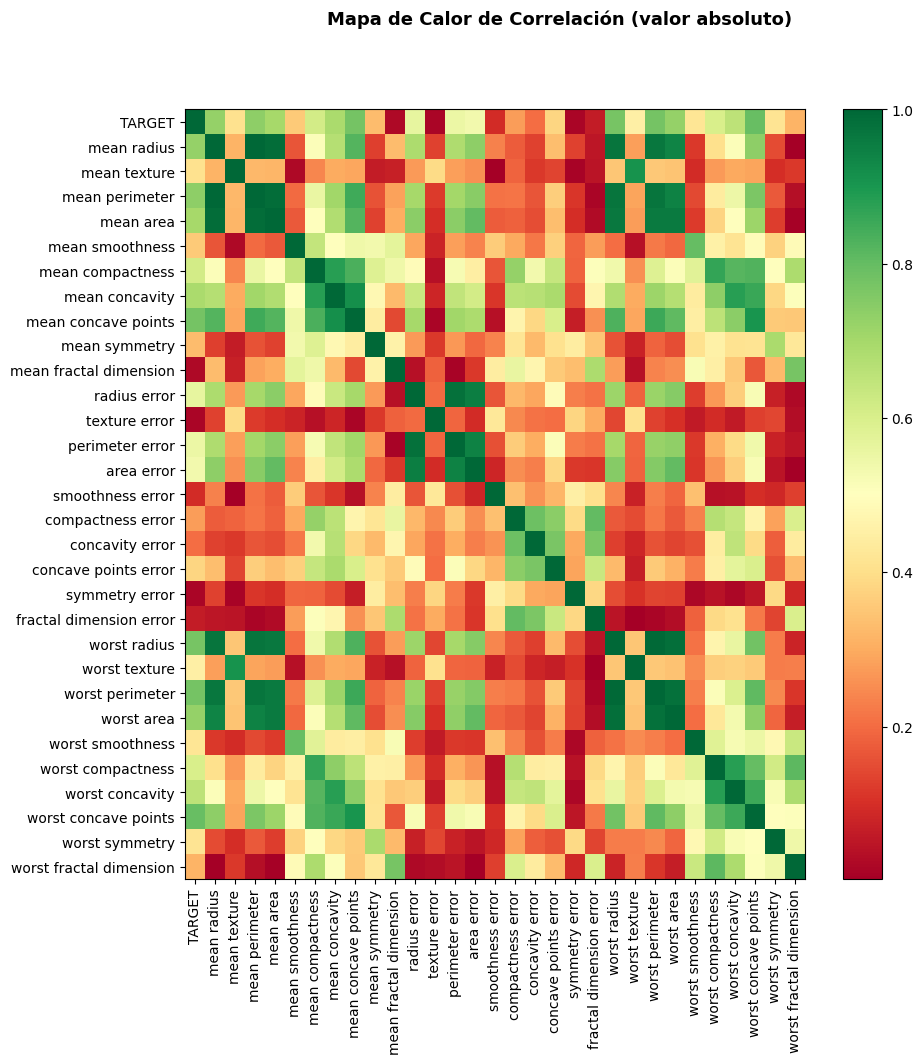

In [26]:
# PASO 3.1
def matriz_correlaciones(y, X, se_dibuja=False):
    # Calcula y dibuja la matriz de correlaciones
    # Devuelve:
    #   yX - datos concatenados
    #   yX_corr - matriz de correlaciones, correlación de Pearson entre [-1, +1]
    #   yX_abs_corr - matriz de correlaciones en valor absoluto

    yX = pd.concat([y, X], axis=1)  # Concatenar los datos de y y X en un solo DataFrame
    yX = yX.rename(columns={0: 'TARGET'})  # Cambiar el nombre de la primera columna a 'TARGET'
    
    # Calcula la matriz de correlación usando el método de Pearson y la convierte en DataFrame
    yX_corr = yX.corr(method='pearson')
    yX_abs_corr = np.abs(yX_corr)  # Convierte la matriz de correlación a valores absolutos
    
    if se_dibuja:
        plt.figure(figsize=(10, 10))
        plt.imshow(yX_abs_corr, cmap='RdYlGn', interpolation='none', aspect='auto')
        plt.colorbar()
        
        # Configura las etiquetas de los ejes
        plt.xticks(range(len(yX_abs_corr)), yX_abs_corr.columns, rotation='vertical')
        plt.yticks(range(len(yX_abs_corr)), yX_abs_corr.columns)
        
        # Título del gráfico
        plt.suptitle('Mapa de Calor de Correlación (valor absoluto)', fontsize=13, fontweight='bold')
        plt.show()

    return yX, yX_corr, yX_abs_corr

# Calcular y visualizar la matriz de correlación de los datos de entrenamiento
yX, yX_corr, yX_abs_corr = matriz_correlaciones(y_train, X_train_0, se_dibuja=True)

# ENTREGA 3

### 1. Entrega el gráfico de la matriz de correlaciones
Se encuentra arriba.

### 2. Una columna influye en el target si su correlación está cerca del +1 o del -1. Como hemos dibujado el valor absoluto en los datos, solo puede estar cera del +1 si tiene influencia o del 0 si no la tiene. Si una columna tiene baja correlación con el target, significa que tienen poca relación y por tanto no tendrá apenas influencia sobre él, no le afecta. Por tanto eliminarla no supone una gran pérdida de información para los algoritmos de aprendizaje. Examinando visualmente la matriz ¿Podrías indicar los nombres de las características que están en ese caso, es decir, tienen una correlación cercana a cero con el target.
Las características que tienen una relación cercana a cero con el target son:
 - Mean fractal dimension.
 - Texture error.
 - Smoothness error.
 - Symmetry error.
 - Fractal dimension error.

Hay otras con una baja relación, pero estas son las cinco más destacables.

### 3. Examinando visualmente la matriz, ¿es simétrica respecto a la diagonal? Es decir (caracteristica1 influye en característica2) lo mismo que (característica2 en característica1)?
La matriz sí es simétrica respecto a la diagonal.

### 4. ¿Qué característica guarda una fuerte correlación con “mean radius” y “mean perimeter”?
La característica que guarda una correlación más fuerte con “mean radius” y “mean perimeter” es: "mean area".

In [27]:
# PASO 3.2

# Reducción univariada
CORRELACION_MIN = 0.1

# Ordenamos características por su correlación con el target
s_corr_target = yX_abs_corr["TARGET"]
s_corr_target_sort = s_corr_target.sort_values(ascending=False)

# Solo usamos columnas con correlación > 0.1
s_low_correlation_ftrs = s_corr_target_sort[s_corr_target_sort <= CORRELACION_MIN]
print(f"Eliminadas {len(s_low_correlation_ftrs)} predictoras:")
for i, v in enumerate(s_low_correlation_ftrs):
    print(
        f"  {i:3d}, {np.round(v, DISPLAY_PRECISION)}, {s_low_correlation_ftrs.index[i]}"
    )

s_corr_target_sort = s_corr_target_sort[s_corr_target_sort > CORRELACION_MIN]
print(f"Quedan {len(s_corr_target_sort)-1} características correlacionadas:")
for i, v in enumerate(s_corr_target_sort):
    ftr = s_corr_target_sort.index[i]
    if ftr == "TARGET":
        continue
    print(f"  {i:3d}, {np.round(v, DISPLAY_PRECISION)}, {ftr}")

Eliminadas 5 predictoras:
    0, 0.0918, smoothness error
    1, 0.0618, fractal dimension error
    2, 0.0253, mean fractal dimension
    3, 0.0176, texture error
    4, 0.0144, symmetry error
Quedan 25 características correlacionadas:
    1, 0.7934, worst concave points
    2, 0.7758, worst perimeter
    3, 0.7758, mean concave points
    4, 0.7702, worst radius
    5, 0.7365, mean perimeter
    6, 0.7243, mean radius
    7, 0.7242, worst area
    8, 0.6995, mean area
    9, 0.691, mean concavity
   10, 0.6558, worst concavity
   11, 0.6123, mean compactness
   12, 0.5986, worst compactness
   13, 0.5628, radius error
   14, 0.5512, perimeter error
   15, 0.5355, area error
   16, 0.4521, worst texture
   17, 0.4204, worst smoothness
   18, 0.4176, worst symmetry
   19, 0.4093, mean texture
   20, 0.3822, concave points error
   21, 0.3606, mean smoothness
   22, 0.3309, mean symmetry
   23, 0.3176, worst fractal dimension
   24, 0.2752, compactness error
   25, 0.2034, concavity err

In [28]:
# PASO 3.3

# Eliminar a los de baja correlación del anterior
li_X1_cols = list(set(s_corr_target_sort.index) - set(s_low_correlation_ftrs.index))
li_X1_cols.remove("TARGET")

# Colinealidad
CORRELACION_MAX = 0.8
X1 = X_train_0[li_X1_cols]
yX1, yX_corr1, yX_abs_corr1 = matriz_correlaciones(y_train, X1, se_dibuja=False)

# Obtener todas las parejas de predictores
Xcorr1 = yX_abs_corr1.iloc[1:, 1:]
s_parejas = Xcorr1.unstack()
print("s_parejas.shape:", s_parejas.shape)
s_parejas = np.round(s_parejas, decimals=DISPLAY_PRECISION)
s_parejas_sorted = s_parejas.sort_values(ascending=False)
s_parejas_sorted = s_parejas_sorted[
    (s_parejas_sorted != 1) & (s_parejas_sorted > CORRELACION_MAX)
]

# Convertir una lista de nombres
li_corr_parejas = s_parejas_sorted.index.tolist()
print("len(li_corr_parejas):", len(li_corr_parejas))
print("li_corr_parejas[:10]:", li_corr_parejas[:10])

s_parejas.shape: (625,)
len(li_corr_parejas): 82
li_corr_parejas[:10]: [(np.str_('mean radius'), np.str_('mean perimeter')), (np.str_('mean perimeter'), np.str_('mean radius')), (np.str_('worst radius'), np.str_('worst perimeter')), (np.str_('worst perimeter'), np.str_('worst radius')), (np.str_('mean area'), np.str_('mean radius')), (np.str_('mean radius'), np.str_('mean area')), (np.str_('mean perimeter'), np.str_('mean area')), (np.str_('mean area'), np.str_('mean perimeter')), (np.str_('worst area'), np.str_('worst radius')), (np.str_('worst radius'), np.str_('worst area'))]


In [29]:
# PASO 3.4

# Calcular lista de predictoras a eliminar
li_remove_parejas = []
li_remove_puntuaciones = []
for tup in li_corr_parejas:
    s0 = s_corr_target_sort.loc[tup[0]]
    s1 = s_corr_target_sort.loc[tup[1]]
    remove_predictora = tup[1] if s1 < s0 else tup[0]  # obtener la < con target
    if remove_predictora not in li_remove_parejas:
        li_remove_parejas.append(remove_predictora)
        di = {
            "var_0": tup[0],
            "var_1": tup[1],
            "coef_0": s0,
            "coef_1": s1,
            "PREDICTORA_A_QUITAR": remove_predictora,
        }
        li_remove_puntuaciones.append(OrderedDict(di))

df_remove_puntuaciones = pd.DataFrame(li_remove_puntuaciones)

# Eliminar predictoras encontradas
print("Eliminando %d predictoras (ver última columna):" % len(li_remove_parejas))
print(df_remove_puntuaciones.to_string())

li_X2_cols = list(set(li_X1_cols) - set(li_remove_parejas))
li_X2_cols.sort()
print("==== Quedan %d predictoras:" % (len(li_X2_cols)))

for i, v in enumerate(s_corr_target_sort):
    ftr = s_corr_target_sort.index[i]
    if ftr in li_X2_cols:
        print(i, np.round(v, DISPLAY_PRECISION), ftr)

Eliminando 16 predictoras (ver última columna):
                   var_0                    var_1  coef_0  coef_1      PREDICTORA_A_QUITAR
0            mean radius           mean perimeter  0.7243  0.7365              mean radius
1           worst radius          worst perimeter  0.7702  0.7758             worst radius
2              mean area              mean radius  0.6995  0.7243                mean area
3             worst area             worst radius  0.7242  0.7702               worst area
4        perimeter error             radius error  0.5512  0.5628          perimeter error
5         mean perimeter          worst perimeter  0.7365  0.7758           mean perimeter
6             area error             radius error  0.5355  0.5628               area error
7         mean concavity      mean concave points  0.6910  0.7758           mean concavity
8          worst texture             mean texture  0.4521  0.4093             mean texture
9   worst concave points      mean concave

# ENTREGA 4

### a) Cuando tenemos dos columnas predictoras con una capacidad predictiva muy parecida, por ejemplo “mean radius” se correlaciona con el target en 0.7108 y la predictora “perimeter” se correlaciona con target 0.7240. ¿Estas dos columnas están correlacionadas entre sí?
Sí, las columnas están relacionadas entre sí, debido a que su capacidad predictiva es muy parecida.

### b) Si es el caso y queremos eliminar una ¿Cuál se debe eliminar?
Se debería eliminar "mean radius" porque su correlación con el target es menor comparado con la variable "perimeter".

==== Tras la reducción con parejas X2.shape: (455, 9)
Las Remaining features:
TARGET                  1.0000
worst concave points    0.7934
radius error            0.5628
worst texture           0.4521
worst smoothness        0.4204
worst symmetry          0.4176
concave points error    0.3822
mean symmetry           0.3309
compactness error       0.2752
concavity error         0.2034
Name: TARGET, dtype: float64
---
Tras la reducción con parejas X3.shape: (455, 9)


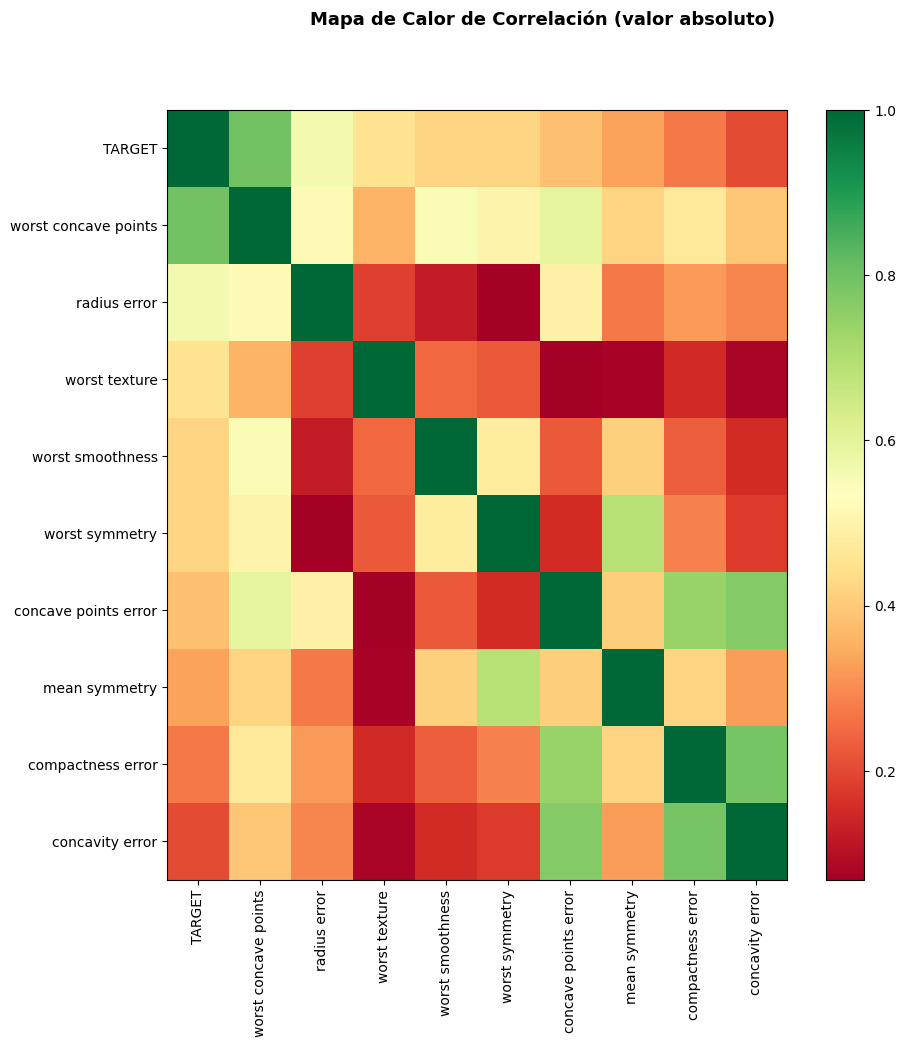

In [30]:
# PASO 3.5

# Calcula la matriz de correlaciones
X2 = X1[li_X2_cols]
print("==== Tras la reducción con parejas X2.shape:", X2.shape)
yX2, yX_corr2, yX_abs_corr2 = matriz_correlaciones(y_train, X2)
s_X3_cols = yX_abs_corr2["TARGET"].sort_values(ascending=False)
li_X3_cols = s_X3_cols.index.tolist()
print("Las Remaining features:")
print(s_X3_cols)
print("---")
li_X3_cols.remove("TARGET")
X3 = X2[li_X3_cols]
print("Tras la reducción con parejas X3.shape:", X3.shape)
yX3, yX_corr3, yX_abs_corr3 = matriz_correlaciones(y_train, X3, se_dibuja=True)
X_train = X3
X_test = X_test_0[li_X3_cols]

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:2219: UserWarning: The marginal plotting function has changed to `histplot`, which does not accept the following argument(s): rug.
  warnings.warn(msg, UserWarning)


Text(0.5, 0.98, 'Ejemplo de matriz de parejas')

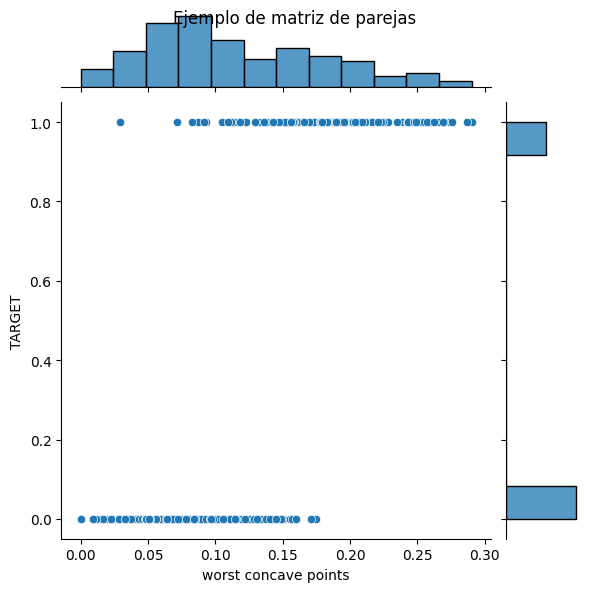

In [31]:
# PASO 3.6

sns.jointplot(
    yX3,
    x="worst concave points",
    y="TARGET",
    kind="scatter",
    marginal_kws=dict(bins=12, rug=True),
)
plt.suptitle("Ejemplo de matriz de parejas")

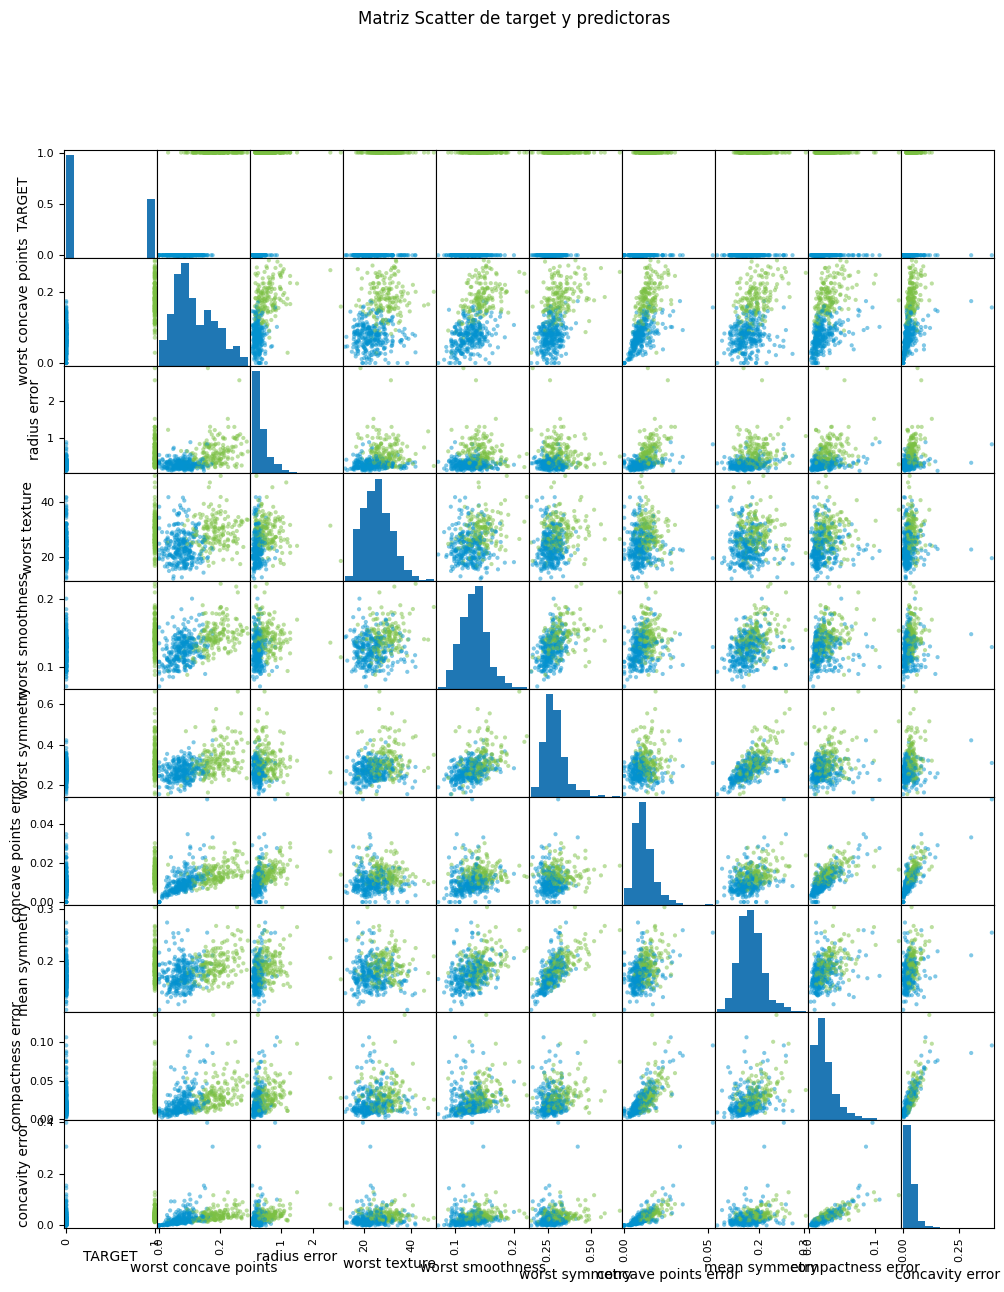

In [32]:
# PASO 3.7

mapa_colores = {0: "#0392cf", 1: "#7bc043"}  # 0(clase negativa):blue, 1(positiva):green
colores = yX3["TARGET"].map(lambda x: mapa_colores.get(x))
pd.plotting.scatter_matrix(
    yX3,
    alpha=0.5,
    color=colores,
    figsize=(12, 14),
    diagonal="hist",
    hist_kwds={"bins": 12},
)
plt.suptitle("Matriz Scatter de target y predictoras")
plt.show()

# ENTREGA 5

### a) Si estas son las predictoras más influyentes en el target ¿Qué porcentaje son de las 30 que teníamos inicialmente?
Aquí aparecen las 9 predictoras más influyentes en el target, que son el `30%` respecto al total que teníamos inicialmente.

### b) Entrega el gráfico.
Se encuentra arriba.

---
# ACTIVIDAD 4

In [33]:
# PASO 4.1

print(f"==== X_train.shape: {X_train.shape}, y_train.shape: {y_train.shape}")

# Distribución de clases de TARGET en train y test
val_cnts = y_train.value_counts()
print("Distribución de ejemplos positivos y negativos en train:")
print(val_cnts)
print("Porcentaje de positivos: %s" % "%.2f%%" % (100 * val_cnts[1] / len(y_train)))

print(f"==== X_test.shape: {X_test.shape}, y_test.shape: {y_test.shape}")
val_cnts = y_test.value_counts()
print("Distribución de ejemplos positivos y negativos en test:")
print(val_cnts)
print("Porcentaje de positivos: %s" % "%.2f%%" % (100 * val_cnts[1] / len(y_test)))

==== X_train.shape: (455, 9), y_train.shape: (455,)
Distribución de ejemplos positivos y negativos en train:
0    290
1    165
Name: count, dtype: int64
Porcentaje de positivos: 36.26%
==== X_test.shape: (114, 9), y_test.shape: (114,)
Distribución de ejemplos positivos y negativos en test:
0    67
1    47
Name: count, dtype: int64
Porcentaje de positivos: 41.23%


# ENTREGA 6

### a) ¿Los datos están balanceados?
Los datos no están del todo balanceados, ya que el porcentaje de positivos en train es de un 39.08% y en test de un 35.44%.

### b) ¿Es lógico porque se corresponde con lo que puedes encontrar en la vida real?
Sí es lógico porque en la vida real los datos no suelen estar balanceados.

### c) Las proporciones de cada clase en train y test ¿Son similares?
Sí son similares, puesto que el porcentaje de positivos en train es de un 39.08% y en test de un 35.44%. Lo que quiere decir que la proporción ha sido parecida.

### d) Si necesitamos datasets muy balanceados se lo podemos pedir a las funciones que particionan los datos. ¿Cómo se llama la técnica que lo realiza? (marca la opción correcta):
 - `Estratificación`
 - Validación cruzada
 - Ingeniería de características
 - ADAM

In [34]:
# PASO 4.2


def plot_2d_grid_search_heatmap(
    grid_search, grid_params, x_param, y_param, is_verbose=True
):
    """
    Dibuja un mapa de calor 2D del proceso grid search.
    Parámetros:
        grid_search: instancia de un objeto sklearn.GridSearchCV
        grid_params: diccionario de parámetros grid search
        x_param: nombre del parámetro eje-x del grid_params
        y_param: nombre del parámetro eje-y del grid_params
        is_verbose (opcional): imprime resultados

    Return:
        grid_search.best_score_: mejor puntuación encontrada
        grid_search.best_estimator_: mejor estimador encontrado
    """
    grid_params_x = grid_params[x_param]
    grid_params_y = grid_params[y_param]
    df_result = pd.DataFrame(grid_search.cv_results_)
    ar_scores = np.array(df_result.mean_test_score).reshape(
        len(grid_params_y), len(grid_params_x)
    )

    sns.heatmap(
        ar_scores,
        annot=True,
        fmt=".3f",
        xticklabels=grid_params_x,
        yticklabels=grid_params_y,
    )
    plt.suptitle("Mapa de Calor Grid Search")
    plt.xlabel(x_param)
    plt.ylabel(y_param)

    if is_verbose:
        print("\n==== grid_search.best_score_:")
        print(grid_search.best_score_)
        print()
        print("grid_search.best_estimator_:")
        print(grid_search.best_estimator_)

    plt.show()
    return grid_search.best_score_, grid_search.best_estimator_

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
35 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
---------------------------------------------------------------


==== grid_search.best_score_:
0.9516483516483516

grid_search.best_estimator_:
LogisticRegression(C=1000, class_weight='balanced', max_iter=200, n_jobs=1,
                   random_state=0)


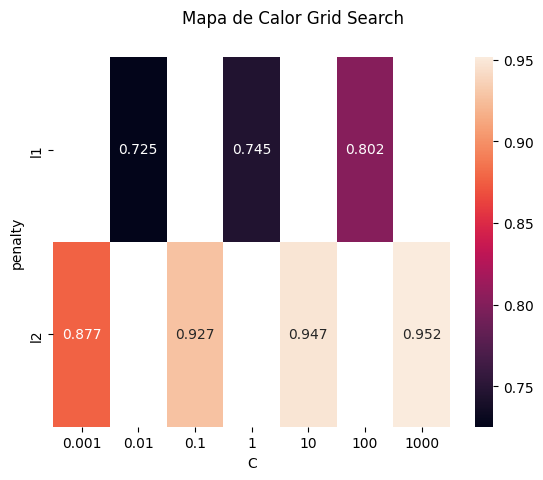

==== Atributo de Clasificador de Regresión Logística:
 intercept_: [-20.86235699]
 coef_: [[ 77.59002661  16.1490818    0.28138403 -18.4280385   19.57744639
  -13.1410181  -18.65360224 -46.18892832 -13.12709997]]


In [35]:
# PASO 4.3

grid_rl = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000], "penalty": ["l1", "l2"]}
cla_rl = LogisticRegression(
    class_weight="balanced",
    dual=False,
    fit_intercept=True,
    intercept_scaling=1,
    max_iter=200,
    n_jobs=1,
    random_state=0,
    tol=0.0001,
    verbose=0,
    warm_start=False,
)

gs_rl = GridSearchCV(cla_rl, grid_rl, return_train_score=True)

# Se realizan por defecto validación cruzada de 3-fold
gs_rl.fit(X_train, y_train)  # Entrenar el modelo
best_score_rl, cla_rl = plot_2d_grid_search_heatmap(gs_rl, grid_rl, "C", "penalty")

print("==== Atributo de Clasificador de Regresión Logística:")
print(" intercept_:", cla_rl.intercept_)
print(" coef_:", cla_rl.coef_)

# ENTREGA 7

### a) ¿Qué valor de hace que se obtenga una puntuación más alta (el modelo funciona mejor)?
El valor que hace que se obtenga una puntuación más alta es C=1000 y penalty=l2.

### b) ¿Significa que no se debe usar regularización?
No, en este caso sí es mejor usar regularización porque la mejor puntuación se obtiene cuando la penalización es l2.

### c) Cuando aplicamos restricciones al algoritmo que configura un modelo, elige:
 - Le damos libertad
 - `Le quitamos libertad`
 - `Hacemos que el modelo generalice mejor`
 - Hacemos que el modelo generalice peor
 - `Es mejor hacerlo cuando el modelo es demasiado complejo y tiene overfitting.`
 - Es mejor hacerlo cuando el modelo es demasiado simple y tiene underfitting.

### d) ¿Qué parámetros configuran al modelo?
Los parámetros que configuran al modelo son los coeficientes del modelo (weights/pesos), que determinan cómo se combinan las características para hacer predicciones.

### e) ¿Con qué hiperparámetros se han calculado esos parámetros?
Los hiperparámetros que se han utilizado en el Grid Search son:
 - C: controla la fuerza de la regularización. Un valor bajo de C implica mayor regularización.
 - penalty: define el tipo de regularización utilizada (l1 o l2).


==== grid_search.best_score_:
0.9362637362637363

grid_search.best_estimator_:
GradientBoostingClassifier(learning_rate=0.01, max_features='sqrt',
                           min_samples_leaf=2, n_estimators=800,
                           random_state=0)


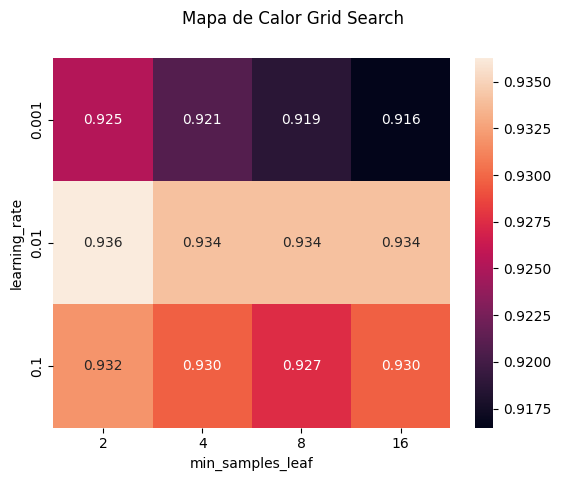

In [36]:
# PASO 4.4

grid_gb = {"min_samples_leaf": [2, 4, 8, 16], "learning_rate": [0.001, 0.01, 0.1]}
cla_gbm = GradientBoostingClassifier(
    criterion="friedman_mse",
    init=None,
    loss="log_loss",
    max_leaf_nodes=None,
    max_features="sqrt",
    max_depth=3,
    warm_start=False,
    min_impurity_decrease=0.0,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    n_estimators=800,
    random_state=0,
    subsample=1.0,
    verbose=0,
)

# Por defecto usa 3-fold CV
gs_gb = GridSearchCV(cla_gbm, grid_gb, verbose=0, return_train_score=True)
gs_gb.fit(X_train, y_train)  # Entrenar modelo
best_score_gb, cla_gb = plot_2d_grid_search_heatmap(
    gs_gb, grid_gb, "min_samples_leaf", "learning_rate"
)

# ENTREGA 8

### a) ¿La mejor puntuación es mejor o peor que la mejor alcanzada por la Regresión Lineal?
La mejor puntuación de la Regresión Lineal es 0.9471804511278196, mientras que la mejor puntuación de este último (Clasfificador GBM) es 0.9259398496240602. Por lo tanto, la puntuación alcanzada ha sido peor comparada con la de Regresión Lineal.

### b) ¿Y el rango de [mínima puntuación, máxima_puntuación]?
Rangos:
 - Regresión Lineal: [0.708, 0.947]
 - Actual: [0.919, 0.926]

Por lo tanto, este último rango ha sido mejor que el de Regresión Lineal.

### c) Si cambiamos el valor de la constante RATIO_PARA_TEST de 0.5 a 0.2, particionamos el 80% de los datos para train. Hazlo y repite la ejecución. ¿Cómo queda ahora la máxima puntuación? ¿Mejora a la Regresión Lineal? ¿El intervalo [peor, mejor]?
Ahora la mejores puntuaciones son:
 - Regresión Lineal: 0.9516483516483516
 - Actual: 0.9362637362637363

Y los intervalos son:
 - Regresión Lineal: [0.725, 0.952]
 - Actual: [0.916, 0.936]

`Conclusión`: la mejor puntuación sigue siendo la de Regresión Lineal y el mejor intervalo sigue siendo el de este último.

### d) ¿Alguno de los dos parámetros no influye cuando se alcanza la mejor puntuación? O dicho de otro modo ¿Hay algún valor óptimo de uno de los dos parámetros?
Cuando el parámetro "min_samples_leaf" es igual a 16, el valor es siempre óptimo. Por lo tanto, el parámetro "learning_rate" es prescindible cuando se llega a este valor.

### e) Cuando usamos GridSearchCV() también debemos usar la función Pipeline() para preprocesar los datos antes de hacer la validación cruzada para entrenar el modelo, algo así como esto: tuberia_de_operaciones = Pipeline([(‘nombre_preproceso1', preproceso1), (‘nombre_modelo', modelo)]) ¿Usamos esto en el código?
En el código no se está utilizando la función Pipeline(), solamente se está utilizando GridSearchCV().

---
# ACTIVIDAD 5

In [37]:
# PASO 5.1

li_clas = ["cla_rl", "cla_gb"]
dfp = pd.DataFrame(index=["TARGET"], data=[y_test]).T
for s_cla in li_clas:
    print("\nMODELO: " + s_cla)
    print("---------------")
    cla = eval(s_cla)
    y_pred = cla.predict(X_test).astype(int)  # devuelve una clase decisión
    y_score = cla.predict_proba(X_test)  # devuelve el valor de probabilidad
    s_class = "%s_class" % s_cla
    s_proba = "%s_proba" % s_cla
    s_rank = "%s_rank" % s_cla
    dfp[s_class] = y_pred
    dfp[s_proba] = y_score[:, 1]
    dfp[s_rank] = dfp[s_proba].rank(ascending=1).astype(int)

    # Imprime la matriz de confusión y el informe de clasificación
    # desde sklearn.metrics importa la matriz de confusión
    # cm = confusion_matrix(y_test, y_pred)
    cm = pd.crosstab(
        y_test, y_pred, rownames=["Reality"], colnames=["Predicted"], margins=True
    )

    print(cm)

    # PASO 5.2
    print("\nInforme de Clasificadores:")
    print(classification_report(y_test, y_pred))
    if s_cla == "cla_rl":
        y_score_lr = y_score.copy()
    elif s_cla == "cla_gb":
        y_score_gb = y_score.copy()
    else:
        print("Error")
        break
    print(dfp.tail(10).to_string())


MODELO: cla_rl
---------------
Predicted   0   1  All
Reality               
0          63   4   67
1           3  44   47
All        66  48  114

Informe de Clasificadores:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95        67
           1       0.92      0.94      0.93        47

    accuracy                           0.94       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114

     TARGET  cla_rl_class  cla_rl_proba  cla_rl_rank
85        1             1        1.0000           99
504       0             0        0.0014           24
400       1             1        0.9933           81
518       0             0        0.3559           64
263       1             0        0.1320           62
213       1             0        0.0212           49
519       0             0        0.0167           48
432       1             1        0.9994           91
516       1          

# ENTREGA 9

### a) Entrega una captura de la matriz de confusión del modelo de Regresión Lineal.
Se encuentra arriba.

### b) Lo mismo para el modelo GBM.
Se encuentra arriba.

# ENTREGA 10

### a) Entrega una captura del informe del modelo de Regresión Lineal.
Se encuentra arriba.

### b) Lo mismo para el modelo GBM.
Se encuentra arriba.

In [38]:
# PASO 5.3

RANGO_BINS = 10
rango_cols = [
    "i_bin",
    "i_min_bin",
    "i_max_bin",
    "score_min",
    "score_max",
    "bin_cnt",
    "pos_cnt",
    "pos_rate",
]
rango_cols2 = [
    "i_bin",
    "score_min",
    "score_max",
    "tnr",
    "fpr",
    "fnr",
    "tpr",
    "tn",
    "fp",
    "fn",
    "tp",
]
print(dfp.shape)
len_test = dfp.shape[0]
len_bin = int(len_test / RANGO_BINS)
for s_cla in li_clas:
    i_min_bin = 0
    i_max_bin = 0
    dfr = pd.DataFrame(columns=rango_cols)
    dfr2 = pd.DataFrame(columns=rango_cols2)
    s_class = "%s_class" % s_cla
    s_proba = "%s_proba" % s_cla
    s_rank = "%s_rank" % s_cla
    for i in range(RANGO_BINS):
        if i == RANGO_BINS - 1:
            i_max_bin = len_test
        else:
            i_max_bin += len_bin

        # Rango usado para cada bin de puntuaciones
        df_rng = dfp[(dfp[s_rank] >= i_min_bin) & (dfp[s_rank] < i_max_bin)]
        score_min = np.min(df_rng[s_proba])
        score_max = np.max(df_rng[s_proba])
        bin_cnt = df_rng.shape[0]
        pos_cnt = len(df_rng[df_rng["TARGET"] == 1])
        pos_rate = pos_cnt / bin_cnt

        # Rango usado para todos los bins hasta i_max_bin
        df_rng_0 = dfp[dfp[s_rank] < i_max_bin]
        df_rng_1 = dfp[dfp[s_rank] >= i_max_bin]

        # targets positivos (tp=true positivos, fn=false negativos)
        tp = len(df_rng_1[df_rng_1["TARGET"] == 1])
        fn = len(df_rng_0[df_rng_0["TARGET"] == 1])
        pos = tp + fn
        tpr = tp / pos
        fnr = 1 - tpr

        # Targets Negativos
        tn = len(df_rng_0[df_rng_0["TARGET"] == 0])
        fp = len(df_rng_1[df_rng_1["TARGET"] == 0])
        neg = tn + fp
        fpr = fp / neg
        tnr = 1 - fpr

        # Hacer el dataframe para resumen de estadísticas por bin
        row = [
            i,
            i_min_bin,
            i_max_bin,
            score_min,
            score_max,
            bin_cnt,
            pos_cnt,
            pos_rate,
        ]
        dfr.loc[i] = row

        # Hacer el dataframe para las estadísticas ROC por bin
        row2 = [i, score_min, score_max, tnr, fpr, fnr, tpr, tn, fp, fn, tp]
        dfr2.loc[i] = row2

        i_min_bin = i_max_bin  # Preparar la siguiente iteración

    if s_cla == "cla_rl":
        dfr_lr = dfr.copy()
        dfr2_lr = dfr2.copy()
    elif s_cla == "cla_gb":
        dfr_gb = dfr.copy()
        dfr2_gb = dfr2.copy()
    else:
        print("Error")
        break

print("==== Resultados de contadores estadísticos positivos por bin")
print("Estadísticas de Regresión Logística:")
print(dfr_lr.to_string())
print()
print("Estadísticas de GBM:")
print(dfr_gb.to_string())
print()
print("...")
print("Estadísticas globales en el test set:")
pos_cnt = len(dfp[dfp["TARGET"] == 1])
pos_rate = pos_cnt / len_test
print("pos_cnt", pos_cnt)
print("total filas", len_test)
print("pos_rate", pos_rate)

(114, 7)
==== Resultados de contadores estadísticos positivos por bin
Estadísticas de Regresión Logística:
   i_bin  i_min_bin  i_max_bin   score_min   score_max  bin_cnt  pos_cnt  pos_rate
0    0.0        0.0       11.0  1.1330e-06  9.2893e-05     10.0      0.0    0.0000
1    1.0       11.0       22.0  1.5464e-04  7.4713e-04     11.0      0.0    0.0000
2    2.0       22.0       33.0  9.3717e-04  3.1325e-03     11.0      0.0    0.0000
3    3.0       33.0       44.0  4.2099e-03  9.2474e-03     11.0      0.0    0.0000
4    4.0       44.0       55.0  1.1241e-02  3.5592e-02     11.0      1.0    0.0909
5    5.0       55.0       66.0  4.1207e-02  3.6121e-01     11.0      2.0    0.1818
6    6.0       66.0       77.0  4.3717e-01  9.6296e-01     11.0      6.0    0.5455
7    7.0       77.0       88.0  9.7479e-01  9.9908e-01     11.0     11.0    1.0000
8    8.0       88.0       99.0  9.9930e-01  9.9983e-01     11.0     11.0    1.0000
9    9.0       99.0      114.0  9.9997e-01  1.0000e+00     15.0

# ENTREGA 11

### a) Entrega una captura de los datos que genera.
Se encuentra arriba.

C:\Users\davil\AppData\Local\Temp\ipykernel_19140\3379999549.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


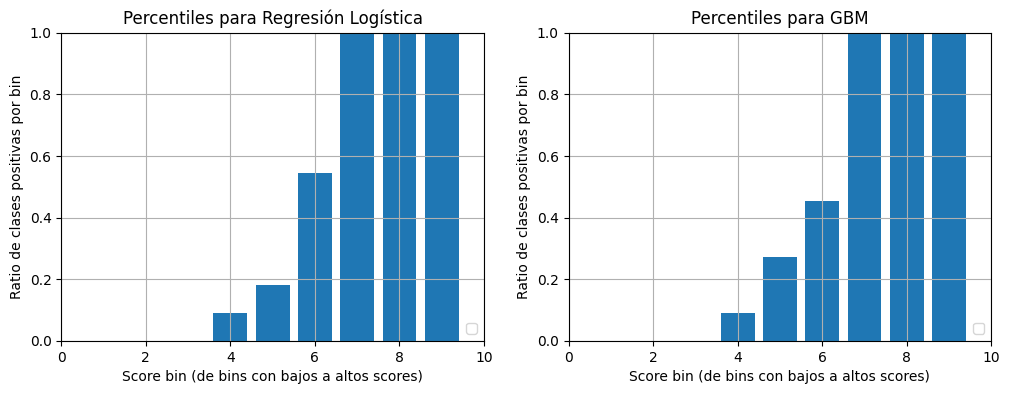

In [39]:
# PASO 5.4

s_titulos = ["Regresión Logística", "GBM"]
plt.figure(figsize=(12, 4))
for i, s_cla in enumerate(li_clas):
    s_titulo = s_titulos[i]
    if s_cla == "cla_rl":
        dfr = dfr_lr
        dfr2 = dfr2_lr
    elif s_cla == "cla_gb":
        dfr = dfr_gb
        dfr2 = dfr2_gb
    else:
        print("Error")
        break

    plt.subplot(1, 2, i + 1)
    plt.bar(dfr["i_bin"], dfr["pos_rate"])
    plt.title("Percentiles para " + s_titulo)
    plt.grid()
    plt.xlabel("Score bin (de bins con bajos a altos scores)")
    plt.ylabel("Ratio de clases positivas por bin")
    plt.legend(loc="lower right")
    plt.xlim([0, RANGO_BINS])
    plt.ylim([0.0, 1])

plt.show()

# ENTREGA 12

### a) Entrega una captura de los gráficos datos que imprime.
Se encuentra arriba.

### b) ¿Hay algún modelo de los que hemos usado que tenga un comportamiento monótono?
En mi opinión, este último modelo tiene un comportamiento monótono porque los bins scores de este se incrementen de manera monótona, es decir, el siguiente de la derecha es mayor que el anterior de su izquierda.

==== Resultados de estadísticas ROC por bin
Estadísticas de Regresión Logística:
   i_bin   score_min   score_max     tnr     fpr     fnr     tpr    tn    fp    fn    tp
0    0.0  1.1330e-06  9.2893e-05  0.1493  0.8507  0.0000  1.0000  10.0  57.0   0.0  47.0
1    1.0  1.5464e-04  7.4713e-04  0.3134  0.6866  0.0000  1.0000  21.0  46.0   0.0  47.0
2    2.0  9.3717e-04  3.1325e-03  0.4776  0.5224  0.0000  1.0000  32.0  35.0   0.0  47.0
3    3.0  4.2099e-03  9.2474e-03  0.6418  0.3582  0.0000  1.0000  43.0  24.0   0.0  47.0
4    4.0  1.1241e-02  3.5592e-02  0.7910  0.2090  0.0213  0.9787  53.0  14.0   1.0  46.0
5    5.0  4.1207e-02  3.6121e-01  0.9254  0.0746  0.0638  0.9362  62.0   5.0   3.0  44.0
6    6.0  4.3717e-01  9.6296e-01  1.0000  0.0000  0.1915  0.8085  67.0   0.0   9.0  38.0
7    7.0  9.7479e-01  9.9908e-01  1.0000  0.0000  0.4255  0.5745  67.0   0.0  20.0  27.0
8    8.0  9.9930e-01  9.9983e-01  1.0000  0.0000  0.6596  0.3404  67.0   0.0  31.0  16.0
9    9.0  9.9997e-01  1.0000e

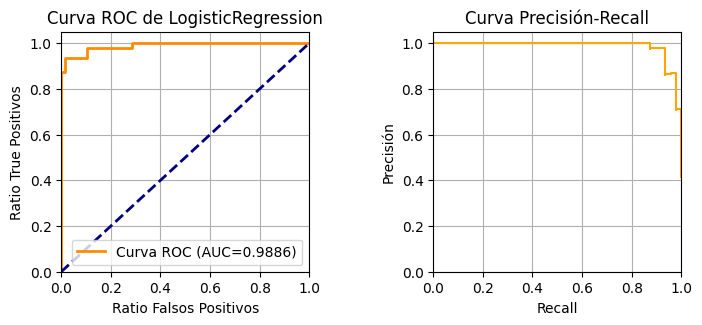



MODELO: cla_gb
---------------


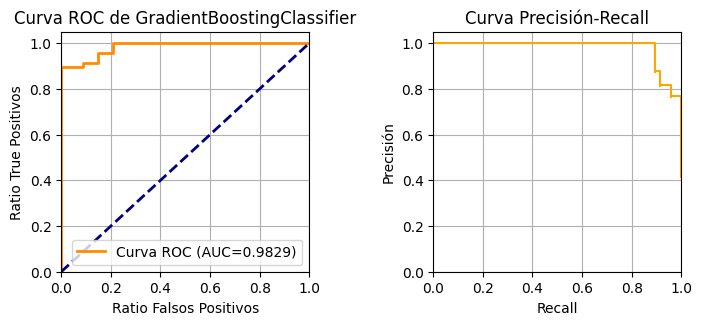

In [40]:
# PASO 5.5

print("==== Resultados de estadísticas ROC por bin")
print("Estadísticas de Regresión Logística:")
print(dfr2_lr.to_string())
print()
print("Estadísticas de GBM:")
print(dfr2_gb.to_string())


def plot_roc_y_precision_recall(y_true, y_score, modelo=None):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)  # Calcula ROC y AUC usando FPR y TPR
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    lw = 2
    plt.plot(
        fpr, tpr, color="darkorange", lw=lw, label="Curva ROC (AUC=%.4f)" % roc_auc
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Ratio Falsos Positivos")
    plt.ylabel("Ratio True Positivos")
    titulo = "Curva ROC"
    if modelo != None:
        titulo = titulo + " de " + modelo.__class__.__name__
    plt.title(titulo)
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.step(recall, precision, color="orange", where="post")
    plt.xlabel("Recall")
    plt.ylabel("Precisión")
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title("Curva Precisión-Recall")
    plt.grid(True)
    plt.subplots_adjust(0.125, 0.1, 0.9, 0.9, 0.5, 0.2)
    plt.show()


for s_cla in li_clas:
    print("\nMODELO: " + s_cla)
    print("---------------")
    cla = eval(s_cla)
    y_pred = cla.predict(X_test).astype(int)
    y_score = cla.predict_proba(X_test)
    plot_roc_y_precision_recall(y_test, y_score[:, 1], cla)
    print()